In [40]:
import pandas as pd
import numpy as np
import os
import glob
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')

from trading_library import *

In [41]:
# Model names and notations
# All models use 252-day rolling window
MODELS = {
    'lr': {
        'name': 'Linear Regression',
        'file': 'predictions_linear_regression_input=2.pkl',
        'col': 'lr',
        'info_col': 'informative_2'
    }
}

In [42]:
# Directories
PROJECT = "C:/Users/skazempour/Dropbox/Projects/42 - Machine learning from the crowd/"
DATA = os.path.join(PROJECT, "Data")
FIGURES = os.path.join(PROJECT, "Figures")
CRSP_FOLDER = "D:/CRSP"

# Input files
INPUT_DATA = os.path.join(DATA, "merged_master.pkl")

# Global parameters
START_DATE = "2012-01-01"
END_DATE = "2022-12-31"
ROLLING_WINDOW = 252

# Load and merge predictions

In [43]:
# Load the original aggregated tweets data
master_data = pd.read_pickle(INPUT_DATA)
master_data = master_data[master_data['date'] >= START_DATE]
df = master_data.copy()

# Load predictions for each model
for model_key, model_info in tqdm(MODELS.items(), desc="Loading predictions"):
    pred_file = os.path.join(DATA, model_info['file'])
    if os.path.exists(pred_file):
        pred_df = pd.read_pickle(pred_file)
        
        # Drop unnecessary columns
        cols_to_drop = [c for c in ['index', 'ticker'] if c in pred_df.columns]
        if cols_to_drop:
            pred_df = pred_df.drop(columns=cols_to_drop)
        
        # Find the rolling window prediction column
        if 'prediction' in pred_df.columns:
            # Keep only date, permno, and rolling prediction
            pred_df = pred_df[['date', 'permno', 'prediction']]
            pred_df.columns = ['date', 'permno', model_info['col']]
            df = pd.merge(df, pred_df, on=['date', 'permno'], how='inner')
            print(f"  Loaded {model_info['name']}: {len(pred_df)} predictions")
        else:
            print(f"  Warning: No prediction column found in {model_info['file']}")
    else:
        print(f"  Warning: File not found - {model_info['file']}")

print(f"\nFinal dataset: {len(df)} observations")

Loading predictions:   0%|          | 0/1 [00:00<?, ?it/s]

  Loaded Linear Regression: 14545760 predictions

Final dataset: 14545760 observations


In [44]:
# for model_key, model_info in MODELS.items():
#     col = model_info['col']
#     df['most_freq'] = df.groupby('date')[col].transform(lambda x: x.mode()[0])
#     df[col] = np.where(df[col] == df['most_freq'], np.nan, df[col])

In [45]:
df = df[df['log_volume'] > 0].reset_index(drop=True)

# Load CRSP daily data

In [46]:
# Find all dsf_final_*.pkl files
crsp_files = sorted(glob.glob(os.path.join(CRSP_FOLDER, "dsf_final_*.pkl")))
print(f"Found {len(crsp_files)} CRSP files from {crsp_files[0]} to {crsp_files[-1]}.")

# Columns to keep
cols_to_keep = ['permno', 'date', 'cap', 'ret']

# Load and combine all files
crsp = [pd.read_pickle(file)[cols_to_keep] for file in tqdm(crsp_files)]

# Combine all dataframes
crsp = pd.concat(crsp, ignore_index=True)

# Clean the data
crsp['f_ret'] = crsp.groupby('permno')['ret'].shift(-1)
crsp['date'] = pd.to_datetime(crsp['date'])

Found 17 CRSP files from D:/CRSP\dsf_final_2008.pkl to D:/CRSP\dsf_final_2024.pkl.


  0%|          | 0/17 [00:00<?, ?it/s]

# Get Fama-French factors

In [47]:
# Download Fama-French 5 factors and momentum factor
import pandas_datareader.data as web

print("Downloading Fama-French 5 factors...", end='')
ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', start=START_DATE, end=END_DATE)[0]
ff5.index = pd.to_datetime(ff5.index, format='%Y%m%d')
ff5 = ff5 / 100  # Convert from percentage to decimal
print("Done!")

print("Downloading momentum factor...", end='')
mom = web.DataReader('F-F_Momentum_Factor_daily', 'famafrench', start=START_DATE, end=END_DATE)[0]
mom.index = pd.to_datetime(mom.index, format='%Y%m%d')
mom = mom / 100  # Convert from percentage to decimal
print("Done!")

# Merge FF5 and momentum into a single dataframe
ff_factors = pd.merge(ff5, mom, left_index=True, right_index=True, how='inner')

In [48]:
all_dates_to_use = np.sort(ff_factors.reset_index()['Date'].unique())
all_dates_to_use = all_dates_to_use[(all_dates_to_use >= pd.Timestamp(START_DATE)) & (all_dates_to_use <= pd.Timestamp(END_DATE))]

# Calculate portfolio returns

In [49]:
df = df[['permno', 'date', 'lr']]

In [50]:
# Merge signals and returns on stock and date columns
merged = pd.merge(df, crsp, on=['permno', 'date'], how='inner', suffixes=('_signal', '_return'))
merged['__signal__'] = merged['lr']

In [51]:
merged = merged.dropna(subset=['__signal__', 'f_ret']) 

# Create deciles based on signals
merged['__decile__'] = merged.groupby('date')['__signal__'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
merged['__decile_max__'] = merged.groupby('date')['__decile__'].transform('max')
merged['__decile_min__'] = merged.groupby('date')['__decile__'].transform('min')
if np.any(merged['__decile_max__'] == merged['__decile_min__']):
    print("Warning: Some dates have only one decile. Consider reducing the number of bins or checking for missing values.")

In [66]:
# Create two portfolios based on signals
long = merged[merged['__decile__'] == merged['__decile_max__']]
short = merged[merged['__decile__'] == merged['__decile_min__']]

In [67]:
long['__weight__'] = long['cap']
short['__weight__'] = short['cap']

long['__ret x weight__'] = long['f_ret'] * long['__weight__']
long = long.groupby('date')[['__ret x weight__', '__weight__', 'permno']].agg({'__ret x weight__': 'sum', '__weight__': 'sum', 'permno': 'count'})
long['long_ret'] = long['__ret x weight__'] / long['__weight__']
long.rename(columns={'permno': 'n_long'}, inplace=True)

short['__ret x weight__'] = short['f_ret'] * short['__weight__']
short = short.groupby('date')[['__ret x weight__', '__weight__', 'permno']].agg({'__ret x weight__': 'sum', '__weight__': 'sum', 'permno': 'count'})
short['short_ret'] = short['__ret x weight__'] / short['__weight__']
short.rename(columns={'permno': 'n_short'}, inplace=True)

portfolio = pd.merge(long[['long_ret', 'n_long']], short[['short_ret', 'n_short']], left_index=True, right_index=True, how='outer')

portfolio['x_date'] = portfolio.index

portfolio = portfolio.reindex(all_dates_to_use)

portfolio = portfolio.shift(1)


In [68]:
portfolio['long >= 10_ret'] = np.where(portfolio['n_long'] >= 10, portfolio['long_ret'], 0)
portfolio['short >= 10_ret'] = np.where(portfolio['n_short'] >= 10, portfolio['short_ret'], 0)
portfolio['long_short_ret'] = portfolio['long_ret'] - portfolio['short_ret']
portfolio['long_short >= 10_ret'] = portfolio['long >= 10_ret'] - portfolio['short >= 10_ret']

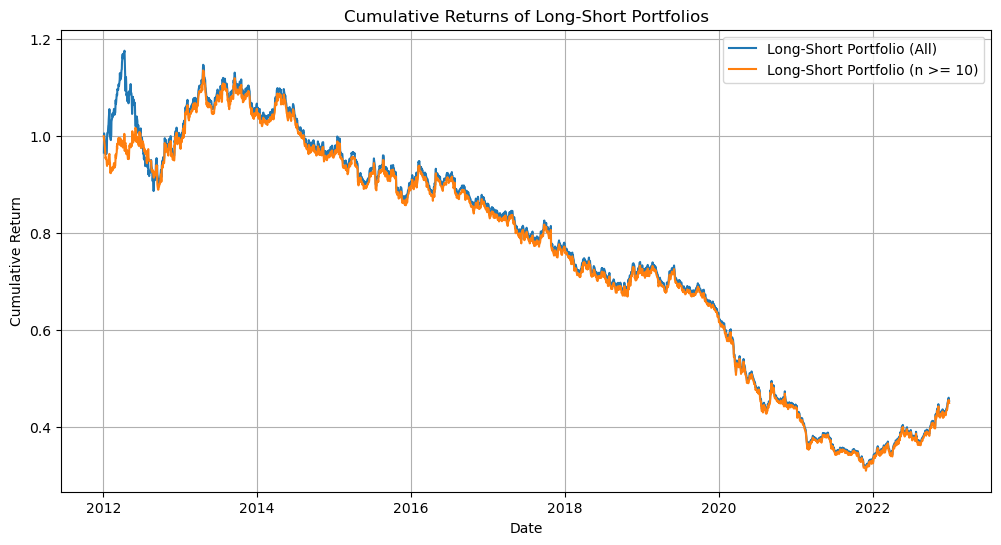

In [69]:
cumret = (1+portfolio['long_short_ret']).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(cumret.index, cumret.values, label='Long-Short Portfolio (All)')
plt.plot((1+portfolio['long_short >= 10_ret']).cumprod(), label='Long-Short Portfolio (n >= 10)')
plt.title('Cumulative Returns of Long-Short Portfolios')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid()

In [70]:
portfolio

,long_ret,n_long,short_ret,n_short,x_date,long >= 10_ret,short >= 10_ret,long_short_ret,long_short >= 10_ret
date,,,,,,,,,
2012-01-03,<NA>,NaN,<NA>,NaN,NaT,0.000000,0.000000,<NA>,0.000000
2012-01-04,-0.030821,3.0,0.003029,110.0,2012-01-03,0.000000,0.003029,-0.033851,-0.003029
2012-01-05,0.043033,1.0,0.001951,60.0,2012-01-04,0.000000,0.001951,0.041082,-0.001951
2012-01-06,-0.00716,12.0,-0.001502,94.0,2012-01-05,-0.007160,-0.001502,-0.005658,-0.005658
2012-01-09,-0.007007,13.0,0.005668,105.0,2012-01-06,-0.007007,0.005668,-0.012675,-0.012675
...,...,...,...,...,...,...,...,...,...
2022-12-23,0.005429,421.0,0.004027,154.0,2022-12-22,0.005429,0.004027,0.001402,0.001402
2022-12-27,0.000412,420.0,-0.020541,140.0,2022-12-23,0.000412,-0.020541,0.020952,0.020952
2022-12-28,-0.013261,551.0,-0.015603,174.0,2022-12-27,-0.013261,-0.015603,0.002342,0.002342
